In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import scipy as sp
from matplotlib import pyplot as plt

# read data
Downloaded from: https://male-cns.janelia.org/ (link provided in the [maleCNS manuscript](https://www.biorxiv.org/content/10.1101/2025.10.09.680999v1)). 

In [2]:
meta = pd.read_feather("~/Downloads/body-annotations-male-cns-v0.9-minconf-0.5.feather")
meta.rename(columns={"bodyId": "bodyid"}, inplace=True)
meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,synonyms,birthtime,mancSerial,mcnsSerial,exitNerve,serialMotif,receptorType,somaLocation,tosomaLocation,status
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,None,...,Kennedy and Broadie 2018: GF,early,NaN,NaN,None,None,None,"[37124, 22258, 36274]",None,Traced
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,None,L,Roughly traced,visual_projection,None,...,None,None,NaN,NaN,None,None,None,"[50214, 10279, 27497]",None,Traced
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,None,...,None,early,NaN,NaN,None,None,None,"[46716, 21029, 15714]",None,Traced
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,None,...,None,early,NaN,NaN,None,None,None,"[41190, 18491, 12885]",None,Traced
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,None,None,NaN,NaN,None,None,None,"[69604, 28368, 42459]",None,Traced
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211738,1571382316,None,NaN,None,None,None,None,Glia,None,None,...,None,None,NaN,NaN,None,None,None,None,None,Glia
211739,1571573938,None,NaN,None,None,None,None,Glia,None,None,...,None,None,NaN,NaN,None,None,None,None,None,Glia
211740,1571585036,None,NaN,None,None,None,None,Glia,None,None,...,None,None,NaN,NaN,None,None,None,None,None,Glia
211741,1571679990,None,NaN,None,None,None,None,Glia,None,None,...,None,None,NaN,NaN,None,None,None,None,None,Glia


In [3]:
meta.columns

Index(['bodyid', 'flywireType', 'group', 'hemibrainType', 'instance',
       'itoleeHl', 'somaSide', 'statusLabel', 'superclass', 'supertype',
       'type', 'class', 'entryNerve', 'fruDsx', 'matchingNotes', 'rootSide',
       'assignedOlHex1', 'assignedOlHex2', 'mancBodyid', 'mancGroup',
       'mancType', 'somaNeuromere', 'subclass', 'trumanHl', 'dimorphism',
       'synonyms', 'birthtime', 'mancSerial', 'mcnsSerial', 'exitNerve',
       'serialMotif', 'receptorType', 'somaLocation', 'tosomaLocation',
       'status'],
      dtype='object')

In [4]:
nt = pd.read_feather("~/Downloads/body-neurotransmitters-male-cns-v0.9.feather")
id2nt = dict(zip(nt.body, nt.consensus_nt))
nt

,body,cell_type,total_nt_predictions,predicted_nt_confidence,predicted_nt,ground_truth,celltype_total_nt_predictions,celltype_predicted_nt,celltype_predicted_nt_confidence,consensus_nt
0,10001,DNp01,1015,0.500352,acetylcholine,None,1991,acetylcholine,0.528112,acetylcholine
1,10002,OCG01d,1443,0.955596,acetylcholine,None,2818,acetylcholine,0.956176,acetylcholine
2,10003,VCH,4425,0.879395,gaba,gaba,8721,gaba,0.874869,gaba
3,10005,AOTU019,2837,0.835142,gaba,gaba,5673,gaba,0.830569,gaba
4,10006,VS,426,0.903854,acetylcholine,acetylcholine,5260,acetylcholine,0.819789,acetylcholine
...,...,...,...,...,...,...,...,...,...,...
1836288,1571851631,None,1,0.910987,unclear,None,1,unclear,NaN,unclear
1836289,1571851794,None,1,0.910987,unclear,None,1,unclear,NaN,unclear
1836290,1571860301,None,1,0.974427,unclear,None,1,unclear,NaN,unclear
1836291,1571860934,None,1,0.974427,unclear,None,1,unclear,NaN,unclear


In [5]:
# remove entries without superclass
meta = meta[meta.superclass.notna()]
# add nt
meta["top_nt"] = meta.bodyid.map(id2nt)

C:\Users\44745\AppData\Local\Temp\ipykernel_146384\2248149833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta["top_nt"] = meta.bodyid.map(id2nt)


In [6]:
conn = pd.read_feather(
    "~/Downloads/connectome-weights-male-cns-v0.9-minconf-0.5.feather"
)
conn = conn[conn.body_pre.isin(meta.bodyid) & conn.body_post.isin(meta.bodyid)]
conn

,body_pre,body_post,weight
0,10352,10351,2591
1,13612,16076,2385
2,10663,10051,2248
3,10289,10611,2230
4,10893,10066,1929
...,...,...,...
151871772,54589,45003,1
151871773,54589,39785,1
151871774,54589,30583,1
151871775,54589,28323,1


In [7]:
# as instructed, remove weight < 5 
# conn = conn[conn.weight >= 5]

In [8]:
# average number of synapses per connection
conn["weight"].mean()

4.853030925345184

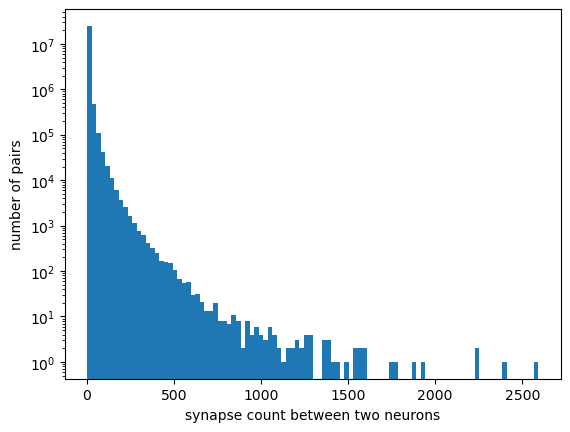

In [9]:
# histogram
plt.hist(conn["weight"], bins=100)

plt.xlabel("synapse count between two neurons")
plt.ylabel("number of pairs")
plt.yscale("log")

In [10]:
# how many neurons are there?
allids = set(conn.body_pre).union(set(conn.body_post))
allids = allids.intersection(set(meta.bodyid))
len(allids)

166473

In [11]:
# how many GB for dense matrix?
len(allids) ** 2 * 4 / 1e9

110.853038916

## exploration

In [12]:
# in connectivity but not meta
len(allids - set(meta.bodyid))

0

In [13]:
# in meta but not connectivity
len(set(meta.bodyid) - allids)

221

In [14]:
# check ones that are not in connectivity
meta[~meta.bodyid.isin(allids)].status.value_counts()

status
Traced         204
Anchor           7
Unimportant      1
Name: count, dtype: int64

There are a few hundred that are roughly traced. 

In [15]:
meta["superclass"].value_counts(dropna=False)

superclass
ol_intrinsic             89399
cb_intrinsic             32163
vnc_intrinsic            13160
visual_projection         9201
vnc_sensory               6374
ol_sensory                6098
cb_sensory                4870
ascending_neuron          1846
descending_neuron         1314
vnc_motor                  720
visual_centrifugal         563
sensory_ascending          536
cb_motor                   107
vnc_efferent               102
endocrine                   72
ENS                         50
vnc_tbc                     40
vnc_sensory_tbc             31
cb_sensory_tbc              14
sensory_descending          12
efferent_ascending           8
efferent_descending          4
cb_efferent                  4
visual_projection_tbc        2
sensory_ascending_tbc        2
descending_neuron_tbc        2
Name: count, dtype: int64

In [16]:
meta["class"].value_counts(dropna=False)

class
None                             140191
visual                             6091
Kenyon_Cell                        4064
CX                                 2950
olfactory                          2639
mechanosensory_tactile             2559
mechanosensory                     1734
unknown_sensory                    1716
mechanosensory_proprioceptive      1454
gustatory                          1428
ALPN                                697
ALLN                                420
DAN                                 340
ol_bilateral                        116
MBON                                 97
hygrosensory                         66
chemosensory                         58
thermosensory                        25
ALIN                                 24
ALON                                 14
mechanosensory_tbc                   11
Name: count, dtype: int64

In [17]:
meta[["somaSide", "rootSide"]].value_counts(dropna=False)

somaSide  rootSide
R         NaN         74219
L         NaN         74042
NaN       R            9700
          L            7755
          unknown       414
M         NaN           392
NaN       NaN           132
L         L              27
R         R              12
L         R               1
Name: count, dtype: int64

# make combined_type column

In [18]:
meta.columns

Index(['bodyid', 'flywireType', 'group', 'hemibrainType', 'instance',
       'itoleeHl', 'somaSide', 'statusLabel', 'superclass', 'supertype',
       'type', 'class', 'entryNerve', 'fruDsx', 'matchingNotes', 'rootSide',
       'assignedOlHex1', 'assignedOlHex2', 'mancBodyid', 'mancGroup',
       'mancType', 'somaNeuromere', 'subclass', 'trumanHl', 'dimorphism',
       'synonyms', 'birthtime', 'mancSerial', 'mcnsSerial', 'exitNerve',
       'serialMotif', 'receptorType', 'somaLocation', 'tosomaLocation',
       'status', 'top_nt'],
      dtype='object')

In [19]:
meta[['flywireType','hemibrainType','type','mancType']].notna().value_counts(dropna=False)

flywireType  hemibrainType  type   mancType
True         False          True   False       106693
             True           True   False        32293
False        False          True   True         20173
                                   False         2730
True         False          True   True          2140
False        False          False  False         1344
True         False          False  False          812
             True           True   True           428
                            False  False           43
False        True           True   False           34
             False          False  True             4
Name: count, dtype: int64

let's say mcns type > flywire type > hemibrain type > manc type > bodyid for now. 

In [20]:
# use type column when there is a value and flywire_type when there is not, and bodyid as a last resort
meta.loc[:, ["combined_type"]] = meta["type"]
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["flywireType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["hemibrainType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["mancType"], inplace=True)
meta.combined_type.replace("", np.nan, inplace=True)

meta.combined_type.fillna(meta["bodyid"].astype(str), inplace=True)
meta.combined_type.isna().sum()

C:\Users\44745\AppData\Local\Temp\ipykernel_146384\1965041994.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  meta.combined_type.replace("", np.nan, inplace=True)
C:\Users\44745\AppData\Local\Temp\ipykernel_146384\1965041994.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta.combined_type.replace("", np.nan, inplace=True)
C:\Users\44

0

In [21]:
# make dictionary that maps bodyid to type
bodyid2type = meta.set_index("bodyid")["combined_type"].to_dict()
bodyid2superclass = meta.set_index("bodyid")["superclass"].to_dict()

# add to conn
conn.loc[:, "comb_type_pre"] = conn.body_pre.map(bodyid2type)
conn.loc[:, "comb_type_post"] = conn.body_post.map(bodyid2type)

In [22]:
# take the intersection of meta and conn
selected_meta = meta[meta.bodyid.isin(allids)]
conn = conn[
    conn.body_pre.isin(selected_meta.bodyid) & conn.body_post.isin(selected_meta.bodyid)
]

In [23]:
# calculate the total post-synapses for each neuron
# do this after removing the ids we don't care about
total_post = conn.groupby("body_post").weight.sum()
total_pre = conn.groupby("body_pre").weight.sum()

# some neurons have no postsynapses (receptors). Let's add those to total_post with value of 0
no_post = allids - set(total_post.index)
no_pre = allids - set(total_pre.index)
len(no_post)

155

In [24]:
no_post_dict = dict(zip(no_post, np.zeros(len(no_post), dtype=int)))
no_pre_dict = dict(zip(no_pre, np.zeros(len(no_pre), dtype=int)))
total_post = pd.concat([total_post, pd.Series(no_post_dict)])
total_pre = pd.concat([total_pre, pd.Series(no_pre_dict)])

# NT

In [25]:
meta.top_nt.value_counts(dropna=False)

top_nt
acetylcholine    99670
glutamate        28998
gaba             22070
histamine         7893
dopamine          4454
unclear           3334
NaN                180
octopamine          51
serotonin           44
Name: count, dtype: int64

In [26]:
# first check consistency of NT within each type
meta.loc[:, ["top_nt"]] = meta["top_nt"].fillna("unclear")
nt_count_per_type = meta.groupby("combined_type")["top_nt"].nunique()
nt_count_per_type[nt_count_per_type > 1]

combined_type
CB1025,CB3573     2
CB1084,CB3534     3
CB1141,CB1285     2
CB1508,CB2021     2
CB2835,CB3123     3
CB3183,CB3796     2
JO-A              2
JO-B              2
JO-C/D/E          2
LHPV2f2,CB1982    2
MeTu1             2
SAch01            2
SLP104,SLP205     2
T2a               2
lLN2X12           2
lLN9,lLN17a       2
Name: top_nt, dtype: int64

In [27]:
# For those with different NT for each neuron, get the majority NT for each type
nt_conflict_types = nt_count_per_type[nt_count_per_type > 1].index

# Getting counts of top_nt for each combined_type
nt_conflict_type_counts = (
    meta[meta.combined_type.isin(nt_conflict_types)]
    .groupby(["combined_type", "top_nt"])
    .size()
)

# Convert the series to a DataFrame and reset index
nt_conflict_type_counts = nt_conflict_type_counts.reset_index(name="counts")

# Sort by combined_type and counts in descending order
nt_conflict_type_counts.sort_values(
    by=["combined_type", "counts"], ascending=[True, False], inplace=True
)

# Initialize dictionary with existing type-nt matching
type_nt = dict(zip(meta.combined_type, meta.top_nt))
# Initialize a list to keep track of types with equal top_nt counts
types_with_equal_top_nt_counts = []


# Custom function to handle ties, random selection, and record keeping
def select_random_nt_and_record_ties(df):
    max_count = df["counts"].max()
    top_nts = df[df["counts"] == max_count]
    if len(top_nts) > 1:  # If there are ties
        types_with_equal_top_nt_counts.append(
            df["combined_type"].iloc[0]
        )  # Record the type with ties
        random_nt = np.random.choice(top_nts["top_nt"].values)
        while random_nt == "unknown":
            random_nt = np.random.choice(top_nts["top_nt"].values)
        return random_nt  # Random selection among ties
    else:
        return top_nts["top_nt"].values[0]


# Loop through each type to get the top_nt, handling ties appropriately
for atype in nt_conflict_types:
    type_df = nt_conflict_type_counts[nt_conflict_type_counts["combined_type"] == atype]
    top_nt = select_random_nt_and_record_ties(type_df)
    type_nt[atype] = top_nt

len(types_with_equal_top_nt_counts)

2

In [28]:
types_with_equal_top_nt_counts

['SLP104,SLP205', 'lLN9,lLN17a']

In [29]:
# the types without any known nt
[atype for atype, nt in type_nt.items() if nt == "unclear"]

['OA-AL2i1',
 'MNx02',
 'DH44',
 'aMe17a',
 'lLN2F_a',
 'SMP001',
 'AN27X013',
 'CvN6',
 'GNG702m',
 'DNp29',
 'DNg34',
 'MeVC27',
 'DNc02',
 'LHPV6q1',
 'AVLP538',
 'PS349',
 'GNG572',
 'CL365',
 'GNG649',
 'DNge138',
 'GNG671',
 'ALIN1',
 'DNp62',
 'SAD078',
 'GNG701m',
 'MN2Db',
 'GNG648',
 'GNG137',
 'MN12D',
 'CL357',
 'CvN5',
 'PVLP106',
 'GNG002',
 'GNG641',
 'CvN7',
 'IPC',
 'DNge047',
 'GNG651',
 'AVLP532',
 '10863',
 'l-LNv',
 'PS348',
 'CAPA',
 'GNG016',
 'Mi19',
 'ALBN1',
 'mAL_m3b',
 'DNd02',
 'LAL123',
 'AVLP594',
 'DNg104',
 'PLP211',
 'CvN4',
 'DMS',
 'GNG650',
 'DNc01',
 'lLN2T_d',
 'SLP438',
 'DNg28',
 'MN4b',
 'DNge149',
 'GNG652',
 'DNge152',
 'v2LN30',
 'v2LN31',
 'DNg26',
 'AVLP593',
 'LoVCLo2',
 'ATL042',
 'SLP457',
 '11851',
 'MN10',
 'GNG276',
 'TmY14',
 'GNG665',
 'GNG647',
 'GNG283',
 'GLNO',
 'GNG314',
 'GNG653',
 'LAL082',
 'NPFL1-I',
 'CL344_b',
 'DSKMP3',
 'ATL031',
 'GNG627',
 'DNge150',
 'PLP259',
 'WED070',
 'PLP260',
 'SLP304',
 'SIP087',
 'GNG668',
 

In [30]:
# update the top_nt column to be consistent within each type
meta.loc[:, ["top_nt"]] = meta.combined_type.map(type_nt)
meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,mancSerial,mcnsSerial,exitNerve,serialMotif,receptorType,somaLocation,tosomaLocation,status,top_nt,combined_type
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,None,...,NaN,NaN,None,None,None,"[37124, 22258, 36274]",None,Traced,acetylcholine,DNp01
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,None,L,Roughly traced,visual_projection,None,...,NaN,NaN,None,None,None,"[50214, 10279, 27497]",None,Traced,acetylcholine,OCG01d
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,None,...,NaN,NaN,None,None,None,"[46716, 21029, 15714]",None,Traced,gaba,VCH
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,None,...,NaN,NaN,None,None,None,"[41190, 18491, 12885]",None,Traced,gaba,AOTU019
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,NaN,NaN,None,None,None,"[69604, 28368, 42459]",None,Traced,acetylcholine,VS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210626,1349927540,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,NaN,NaN,None,None,None,None,None,Traced,acetylcholine,SNxx33
210837,1387178136,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,NaN,NaN,None,None,None,None,None,Traced,acetylcholine,SNpp45
210905,1399810824,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,NaN,NaN,None,None,None,None,None,Traced,acetylcholine,SNta34
211084,1434599043,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,NaN,NaN,None,None,None,None,None,Traced,acetylcholine,SNta31


In [31]:
meta.top_nt.value_counts(dropna=False)

top_nt
acetylcholine    99740
glutamate        29005
gaba             22070
histamine         7893
dopamine          4454
unclear           3437
octopamine          51
serotonin           44
Name: count, dtype: int64

In [32]:
# for now regarding everything (ACh, Glu, GABA, Dopamine, Serotonine, ??) except for Glu and GABA to be excitatory
# first make a dictionary
nt_value = {
    "acetylcholine": 1,
    "glutamate": -1,
    "gaba": -1,
    "histamine": 1,
    "dopamine": 1,
    "serotonin": 1,
    "octopamine": 1,
    "unclear": 1,
}

# make coo

In [33]:
# instead of making a dense matrix based on the edgelist above, let's make a sparse one from the edgelist directly
# first make a coo matrix
sorted_nodes = sorted(allids)  # Convert the set to a sorted list
nodes_to_idx = {node: int(num) for num, node in enumerate(sorted_nodes)}

# neuron to neuron connectivity
conn.loc[:, ["pre_idx"]] = conn.body_pre.map(nodes_to_idx)
conn.loc[:, ["post_idx"]] = conn.body_post.map(nodes_to_idx)

# Create COO matrix
row = conn["pre_idx"].values
col = conn["post_idx"].values
data = conn["weight"].values
matrix_size = len(sorted_nodes)
coo = coo_matrix((data, (row, col)), shape=(matrix_size, matrix_size))

# then turn it into csc matrix
csc = coo.tocsc()

# calculate the size
csc_size = csc.data.nbytes  # Size of the data array
csc_size += csc.indices.nbytes  # Size of the indices array
csc_size += csc.indptr.nbytes  # Size of the index pointer array
# number of MB
csc_size / 1e6

307.526044

In [34]:
csc.shape

(166473, 166473)

In [35]:
csc

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 25571679 stored elements and shape (166473, 166473)>

In [36]:
sp.sparse.save_npz("../data/maleCNS/mcns_syncount_all_neuron.npz", csc)

In [37]:
# re-order so that it matches order of nodes
total_post = total_post.loc[sorted_nodes]
total_pre = total_pre.loc[sorted_nodes]
total_post

10001         16051
10002           367
10003         26341
10005         31380
10006         19503
              ...  
1349927540        3
1387178136        3
1399810824       46
1434599043       33
1471062202       25
Length: 166473, dtype: int64

In [38]:
# Handling division by zero in case some columns have a sum of zero
# that is, where a neuron doesn't have incoming synapses
col_sums_with_inversion = np.reciprocal(
    total_post.to_numpy().astype(float), where=total_post.to_numpy() != 0
)
# Multiply each column by the inverse of its sum
inprop = csc.multiply(col_sums_with_inversion)
# and then reduce the precision to float32 to save memory
inprop = inprop.astype(np.float32)

In [39]:
sp.sparse.save_npz("../data/maleCNS/mcns_inprop_all_neuron.npz", inprop)

In [40]:
row_sums_with_inversion = np.reciprocal(
    total_pre.to_numpy().astype(float), where=total_pre.to_numpy() != 0
)
# Multiply each row by the inverse of its sum
outprop = csc.multiply(row_sums_with_inversion[:, None])
outprop = outprop.astype(np.float32)
sp.sparse.save_npz("../data/maleCNS/mcns_outprop_all_neuron.npz", outprop)

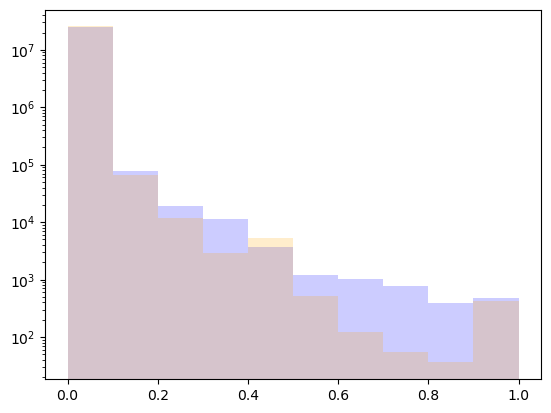

In [41]:
# histogram of connection strengths
plt.hist(inprop.data, alpha=0.2, label="inprop", color="blue")
plt.hist(outprop.data, alpha=0.2, label="outprop", color="orange")
plt.yscale("log")
plt.show()

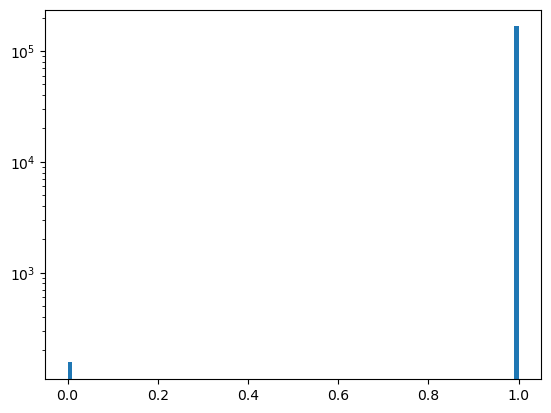

In [42]:
# histogram of column sums
colsums = inprop.sum(axis=0)
plt.hist(colsums.A1, bins=100)
plt.yscale("log")
plt.show()

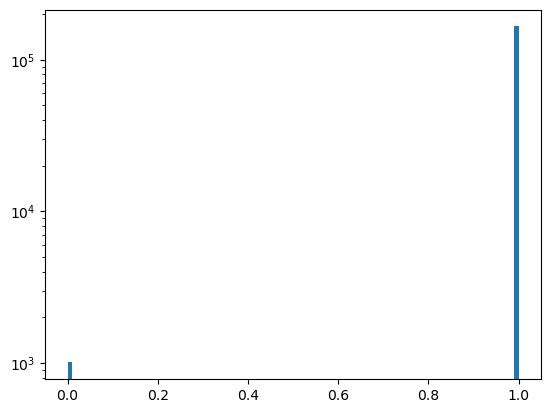

In [43]:
# histogram of row sums
rowsums = outprop.sum(axis=1)
plt.hist(rowsums.A1, bins=100)
plt.yscale("log")
plt.show()

# add hex coordinates

In [44]:
cols = pd.read_csv(
    "https://raw.githubusercontent.com/YijieYin/connectome_interpreter/refs/heads/main/connectome_interpreter/data/Nern2024/ME-columnar-cells-hex-location.csv"
)
cols["coords"] = cols["x"].astype(str) + "," + cols["y"].astype(str)
# make longer, remove columns hex1_id, hex2_id, x, y
cols = cols[
    [
        "L1",
        "L2",
        "L3",
        "L5",
        "Mi1",
        "Mi4",
        "Mi9",
        "C2",
        "C3",
        "Tm1",
        "Tm2",
        "Tm4",
        "Tm9",
        "Tm20",
        "T1",
        "coords",
    ]
].melt(id_vars=["coords"], var_name="cell_type", value_name="bodyId")
cols = cols[~cols.bodyId.isna()]
cols["bodyId"] = cols["bodyId"].astype(int)
cols

,coords,cell_type,bodyId
0,"6,8",L1,94444
1,"7,9",L1,65625
2,"9,11",L1,77697
3,"3,7",L1,107494
4,"4,8",L1,90008
...,...,...,...
13795,"-4,68",T1,71662
13796,"-3,69",T1,72225
13797,"-3,69",T1,72225
13798,"-2,70",T1,66447


In [45]:
# map from bodyid to coordinates
bodyid_to_coords = cols.set_index("bodyId")["coords"].to_dict()
selected_meta["coords"] = selected_meta.bodyid.map(bodyid_to_coords)
selected_meta[["type", "coords"]].value_counts().reset_index().sort_values("type")

C:\Users\44745\AppData\Local\Temp\ipykernel_146384\2616589617.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_meta["coords"] = selected_meta.bodyid.map(bodyid_to_coords)


,type,coords,count
8780,C2,"-2,44",1
8823,C2,"-1,35",1
8824,C2,"-1,15",1
8825,C2,"-1,17",1
8826,C2,"-1,19",1
...,...,...,...
4426,Tm9,"9,57",1
4427,Tm9,"9,59",1
4428,Tm9,"9,61",1
4418,Tm9,"9,41",1


In [46]:
# save to csv, one row is one neuron
selected_meta.loc[:, ["idx"]] = selected_meta.bodyid.map(nodes_to_idx)
selected_meta.loc[:, ["sign"]] = selected_meta.top_nt.map(nt_value)
selected_meta.rename(columns={"combined_type": "cell_type"}, inplace=True)

# adult, right hemisphere, neuron level, selected_meta information
selected_meta.to_csv("../data/maleCNS/mcns_all_neuron_meta.csv")

C:\Users\44745\AppData\Local\Temp\ipykernel_146384\1125413997.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_meta.rename(columns={"combined_type": "cell_type"}, inplace=True)


In [47]:
selected_meta

,bodyid,flywireType,group,hemibrainType,instance,itoleeHl,somaSide,statusLabel,superclass,supertype,...,serialMotif,receptorType,somaLocation,tosomaLocation,status,top_nt,cell_type,coords,idx,sign
0,10001,DNp01,10001.0,Giant Fiber,DNp01(GF)_R,putative_primary,R,Roughly traced,descending_neuron,None,...,None,None,"[37124, 22258, 36274]",None,Traced,acetylcholine,DNp01,NaN,0,1.0
1,10002,OCG01d,10002.0,OCG01,OCG01d_L,None,L,Roughly traced,visual_projection,None,...,None,None,"[50214, 10279, 27497]",None,Traced,acetylcholine,OCG01d,NaN,1,1.0
2,10003,VCH,10003.0,VCH,VCH_R,putative_primary,R,Prelim Roughly traced,visual_centrifugal,None,...,None,None,"[46716, 21029, 15714]",None,Traced,gaba,VCH,NaN,2,-1.0
3,10005,AOTU019,10005.0,AOTU019,AOTU019_R,putative_primary,R,Roughly traced,cb_intrinsic,None,...,None,None,"[41190, 18491, 12885]",None,Traced,gaba,AOTU019,NaN,3,-1.0
4,10006,"VS1,VS2,VS3,VS4,VS5,VS6,VS7,VS8",10006.0,VS,VS_L,no_lineage,L,Prelim Roughly traced,visual_projection,10006,...,None,None,"[69604, 28368, 42459]",None,Traced,acetylcholine,VS,NaN,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210626,1349927540,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,None,None,None,None,Traced,acetylcholine,SNxx33,NaN,166468,1.0
210837,1387178136,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,None,None,None,None,Traced,acetylcholine,SNpp45,NaN,166469,1.0
210905,1399810824,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,None,None,None,None,Traced,acetylcholine,SNta34,NaN,166470,1.0
211084,1434599043,None,NaN,None,None,None,None,Reviewed,vnc_sensory,None,...,None,None,None,None,Traced,acetylcholine,SNta31,NaN,166471,1.0
